# HealthCost AI — Data Exploration
## Step 1: Load & Validate Dataset (Medical Insurance Cost)
Dataset: age, sex, bmi, children, smoker, region → target: charges

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/medical_insurance.csv')
print(df.shape)
df.head()

(2772, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Overview
Checking structure, data types, missing values, and duplicates.


In [3]:
df.info()
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB

Duplicate rows: 1435

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Remove Duplicates

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
df.describe(include='all')

(1337, 7)


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


## Target Distribution

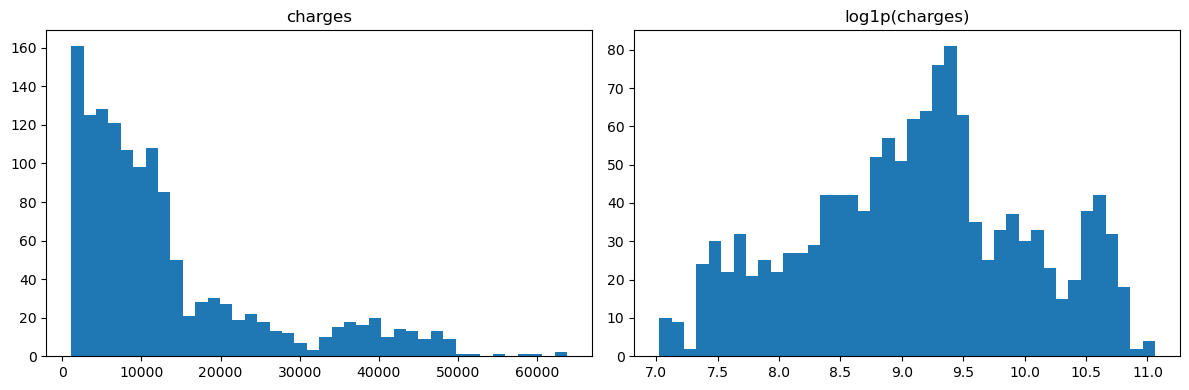

Skewness (charges): 1.5153909108403483
Skewness (log1p charges): -0.08955835073325419


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['charges'], bins=40)
axes[0].set_title('charges')
axes[1].hist(np.log1p(df['charges']), bins=40)
axes[1].set_title('log1p(charges)')
plt.tight_layout()
plt.show()

print("Skewness (charges):", df['charges'].skew())
print("Skewness (log1p charges):", np.log1p(df['charges']).skew())

## Feature Relationships with Target

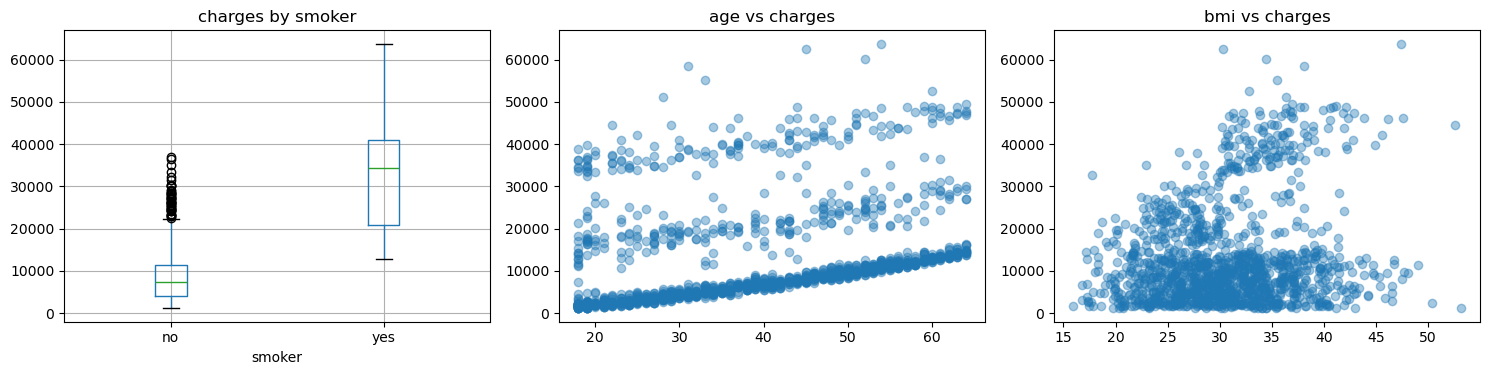

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='charges', by='smoker', ax=axes[0])
axes[0].set_title('charges by smoker')

axes[1].scatter(df['age'], df['charges'], alpha=0.4)
axes[1].set_title('age vs charges')

axes[2].scatter(df['bmi'], df['charges'], alpha=0.4)
axes[2].set_title('bmi vs charges')

plt.suptitle('')
plt.tight_layout()
plt.show()

df.groupby('smoker')['charges'].mean()

## BMI–Smoker Interaction

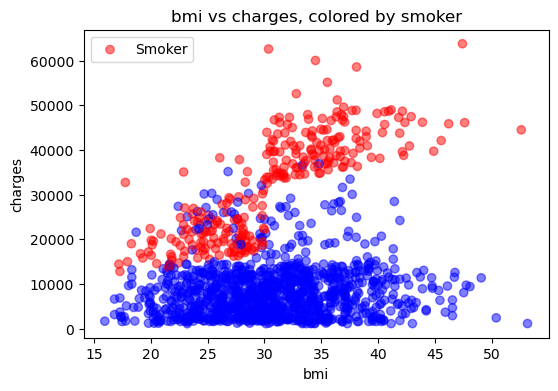

In [14]:
colors = df['smoker'].map({'yes': 'red', 'no': 'blue'})
plt.figure(figsize=(6, 4))
plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5)
plt.xlabel('bmi')
plt.ylabel('charges')
plt.title('bmi vs charges, colored by smoker')
plt.legend(['Smoker', 'Non-smoker'])
plt.show()

## Categorical Features: sex & region
Quick check for any strong effect before moving to preprocessing.

In [15]:
print(df.groupby('sex')['charges'].mean())
print()
print(df.groupby('region')['charges'].mean())

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


## Summary

**Data:**
- Source file had 2772 rows with 1435 duplicates; cleaned dataset has 1337 unique rows, no missing values.
- Columns: age, sex, bmi, children, smoker, region → target: charges

**Key findings:**
- `charges` is right-skewed (skew ≈ 1.52); `log1p(charges)` is nearly symmetric (skew ≈ -0.09) → apply log-transform for training, `expm1` to invert at inference.
- `smoker` is by far the strongest predictor: mean charges ~$32,050 (smoker) vs ~$8,441 (non-smoker).
- `bmi × smoker` interaction matters: charges rise sharply for smokers with BMI ≥ 30, much less so for non-smokers.
- `age` has a mild positive relationship with charges within each smoker group.
- `sex` and `region` have weak effects on charges (differences of ~$1,000-2,400) compared to smoker (~$24,000).

**Decisions carried into preprocessing:**
- Target: train on `log1p(charges)`, invert with `expm1` for predictions.
- Keep all 6 features; no leakage risk identified.
- No missing-value imputation needed for this dataset, but pipeline should still include an imputer step for robustness/reusability.

**Next:** preprocessing pipeline notebook — ColumnTransformer (encoding + scaling) and train/test split.